In [58]:
#setup environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("Environment setup successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Environment setup successful!
NumPy version: 2.4.6
Pandas version: 3.0.3
Scikit-Learn version: 1.8.0


In [59]:
#loading dataset
df = pd.read_csv("insurance.csv")
print(df.head(5))
print(df.shape) #shape is (1338, 7) which means there are 1338 rows and 7 columns
print(df.isnull().sum()) #checking for missing values

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


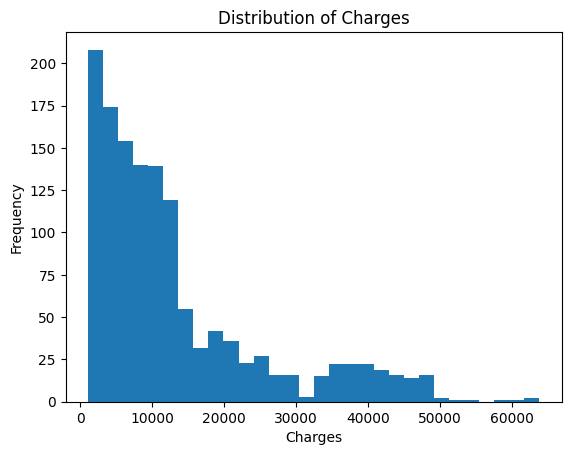

In [60]:
plt.hist(df["charges"], bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Charges")
plt.show()

In [61]:
df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

In [62]:
df["sex_male"] = df["sex_male"].astype(int)
df["smoker_yes"] = df["smoker_yes"].astype(int)
df["region_northwest"] = df["region_northwest"].astype(int)
df["region_southeast"] = df["region_southeast"].astype(int)
df["region_southwest"] = df["region_southwest"].astype(int)

print(df.head(5))
print(df.shape) #shape is (1338, 9)

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  
(1338, 9)


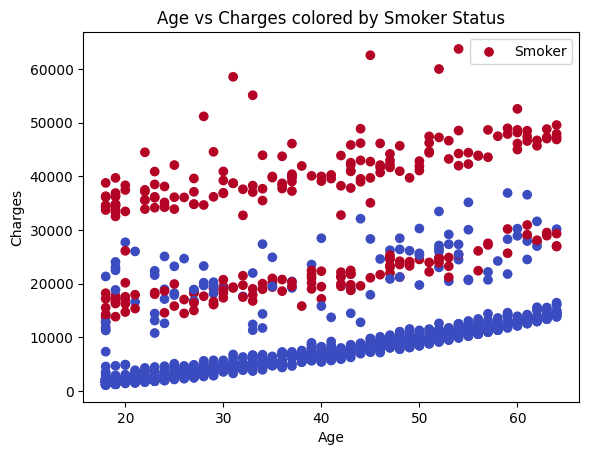

In [63]:
plt.scatter(df["age"], df["charges"], c=df["smoker_yes"], cmap="coolwarm")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges colored by Smoker Status")
plt.legend(["Smoker"])
plt.show()

In [64]:
#splitting data into training and testing sets
y = df["charges"]
X = df.drop("charges", axis=1)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
#feature scaling using z-score normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
#training a linear regression model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = lr_model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 33596915.85136148
R^2 Score: 0.7835929767120722


In [68]:
#exploring polynomial features to capture non-linear relationships
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X_train_scaled)
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after polynomial transformation: {poly_features.shape[1]}")

Original number of features: 8
Number of features after polynomial transformation: 44


In [69]:
lr_poly_model = LinearRegression()
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lr_poly_model.fit(X_train_poly, y_train)
y_poly_pred = lr_poly_model.predict(X_test_poly)
r2_train_poly = r2_score(y_train, lr_poly_model.predict(X_train_poly))
print(f"Polynomial R^2 Score on Training Set: {r2_train_poly}")
r2_test_poly = r2_score(y_test, y_poly_pred)
print(f"Polynomial R^2 Score on Test Set: {r2_test_poly}")

Polynomial R^2 Score on Training Set: 0.8418173231535121
Polynomial R^2 Score on Test Set: 0.866583090316484


In [70]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_poly, y_train)
y_ridge_pred = ridge_model.predict(X_test_poly)
r2_ridge = r2_score(y_test, y_ridge_pred)
mse_ridge = mean_squared_error(y_test, y_ridge_pred)
print(f"Ridge Regression R^2 Score on Test Set: {r2_ridge}")
print(f"RMSE for Ridge Regression: {np.sqrt(mse_ridge)}")

Ridge Regression R^2 Score on Test Set: 0.8666304091796793
RMSE for Ridge Regression: 4550.325240511021


In [71]:
coefficients = ridge_model.coef_
feature_names = poly.get_feature_names_out(X.columns)
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
print(coef_df.sort_values(by="Coefficient", ascending=False))

                              Feature  Coefficient
34                       smoker_yes^2  4474.032993
0                                 age  3587.359076
19                     bmi smoker_yes  3562.418423
4                          smoker_yes  3070.997311
1                                 bmi  1960.132689
2                            children   861.170211
8                               age^2   775.178923
15               age region_southwest   356.541051
32          sex_male region_southeast   322.689315
14               age region_southeast   300.828054
31          sex_male region_northwest   263.299142
37        smoker_yes region_southwest   245.627171
42  region_southeast region_southwest   154.843674
13               age region_northwest   138.660954
33          sex_male region_southwest   134.599203
40  region_northwest region_southwest   134.380251
11                       age sex_male   121.069632
39  region_northwest region_southeast   101.920913
17                       bmi ch

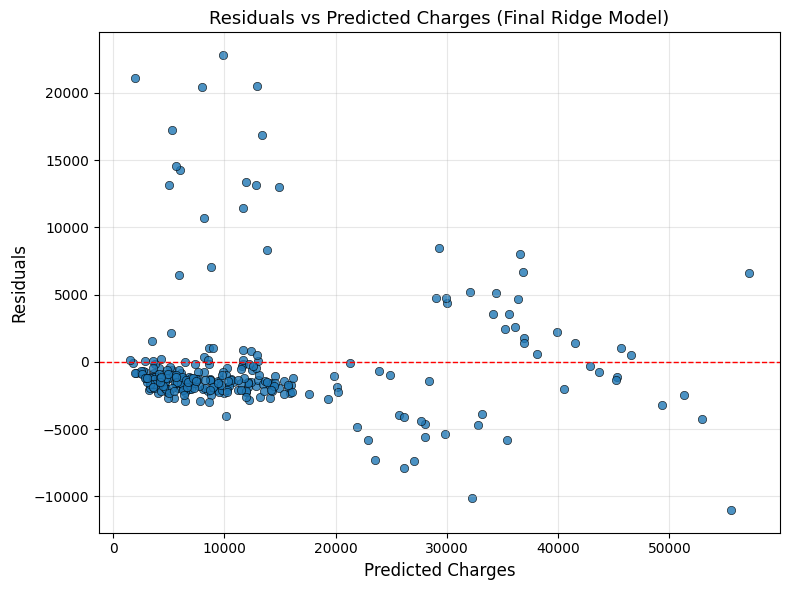

Saved: residual_plot.png


In [72]:
residuals = y_test - y_ridge_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_ridge_pred, residuals, alpha=0.8, edgecolor='k', linewidth=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Charges", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residuals vs Predicted Charges (Final Ridge Model)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: residual_plot.png")

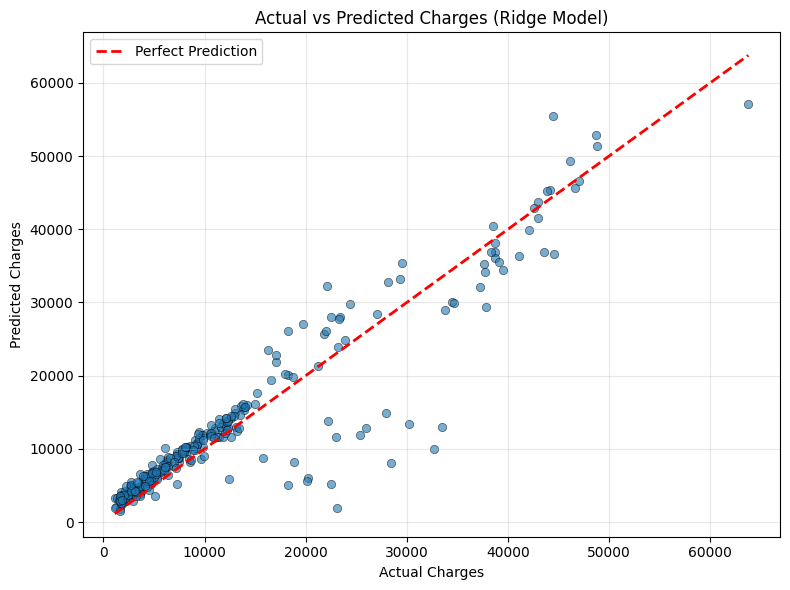

Saved: actual_vs_predicted.png


In [73]:
# Plot 1: Actual vs Predicted Charges
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_ridge_pred, alpha=0.6, edgecolor='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (Ridge Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

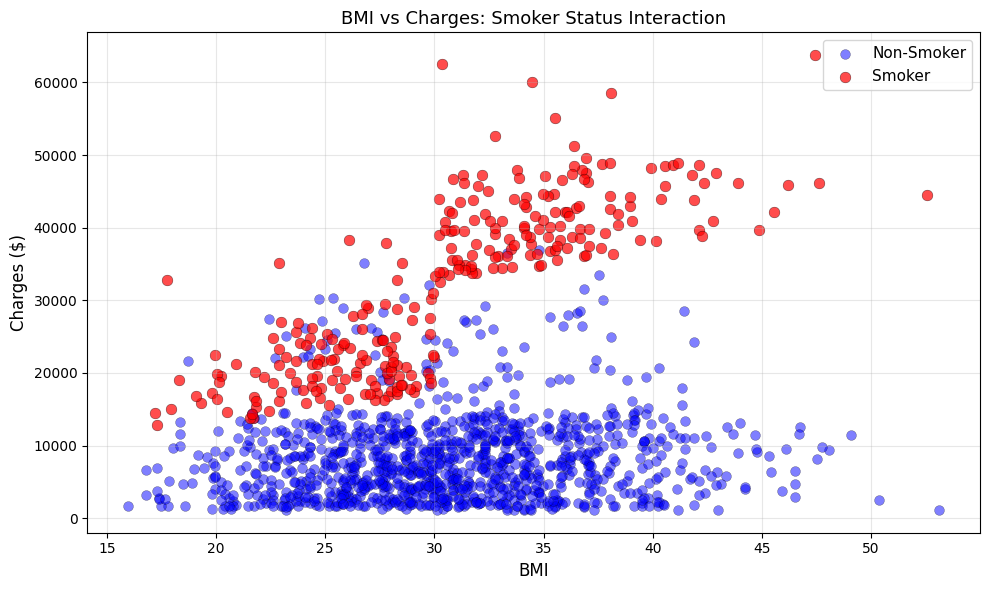

Saved: bmi_smoker_interaction.png


In [74]:
# Plot 2: BMI vs Charges Interaction (Smoker Highlighted)
plt.figure(figsize=(10, 6))
# Get original data with smoker information
df_plot = df.copy()
smokers = df_plot[df_plot['smoker_yes'] == 1]
non_smokers = df_plot[df_plot['smoker_yes'] == 0]

plt.scatter(non_smokers['bmi'], non_smokers['charges'], alpha=0.5, label='Non-Smoker', color='blue', s=50, edgecolor='k', linewidth=0.3)
plt.scatter(smokers['bmi'], smokers['charges'], alpha=0.7, label='Smoker', color='red', s=60, edgecolor='k', linewidth=0.3)

plt.xlabel("BMI", fontsize=12)
plt.ylabel("Charges ($)", fontsize=12)
plt.title("BMI vs Charges: Smoker Status Interaction", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/bmi_smoker_interaction.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: bmi_smoker_interaction.png")

In [75]:
import joblib
joblib.dump(ridge_model, "insurance_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']